In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe


In [2]:

import visualizations as vis

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the aggregated California example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [3]:
deep_reload(good)
graph = good.graph.graph_from_json('Examples/California.json')

graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

First we will run the grid with custom policies

In [4]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = good.utilities.read_json('Examples/policies.json')

In [5]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 0.7776720523834229
Variables Built: 0.4546949863433838
Constraints Built: 4.271078824996948
Objective Built: 0.14526009559631348


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 201520, continuous_variables = 74292, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74292), overall = Bunch(binary_variables = 0, constraints = 201520, continuous_variables = 74292, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74292), warning = Bunch(unassociated_disjuncts = 0))

In [6]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 7.963158130645752
Objective Value: 28230791.213176027


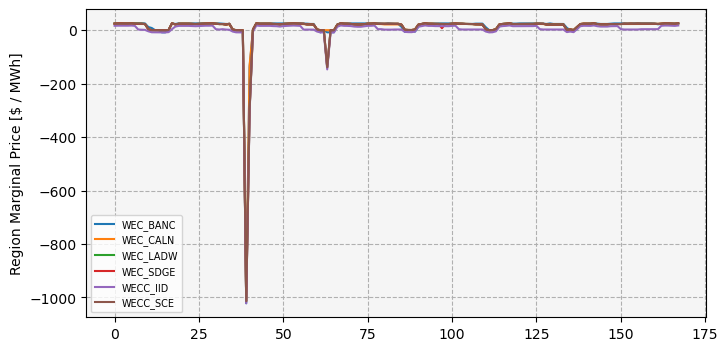

In [7]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

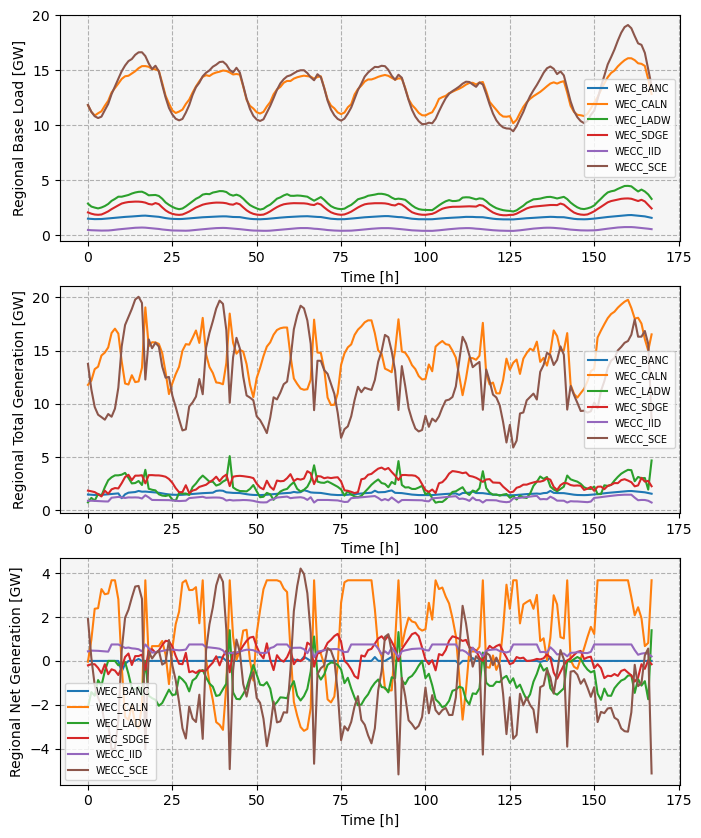

In [8]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

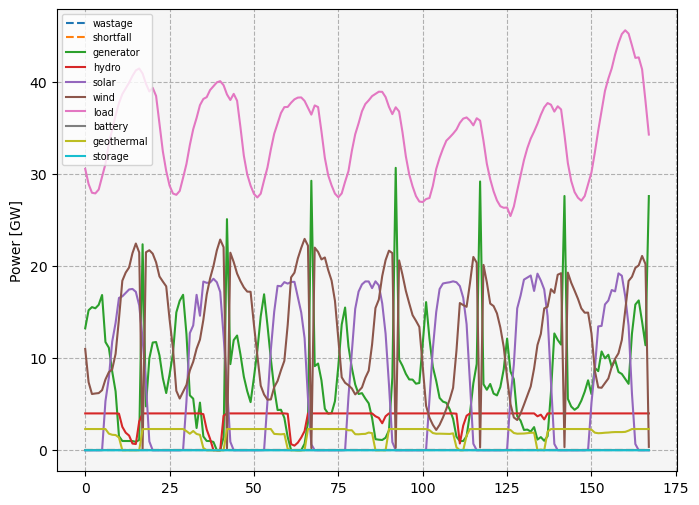

In [9]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

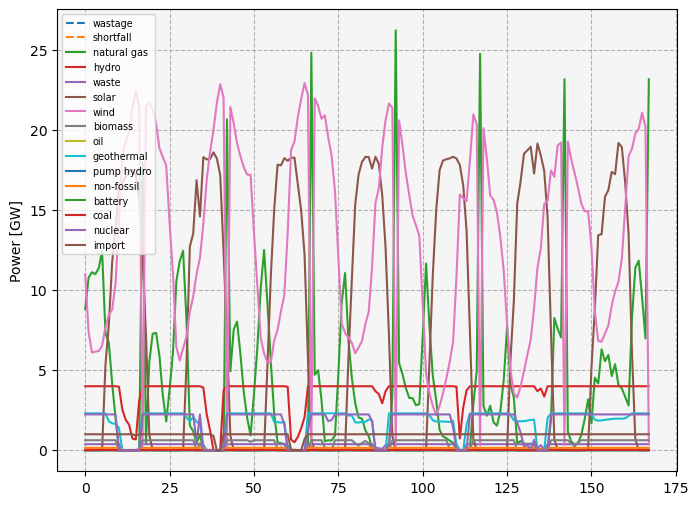

In [10]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


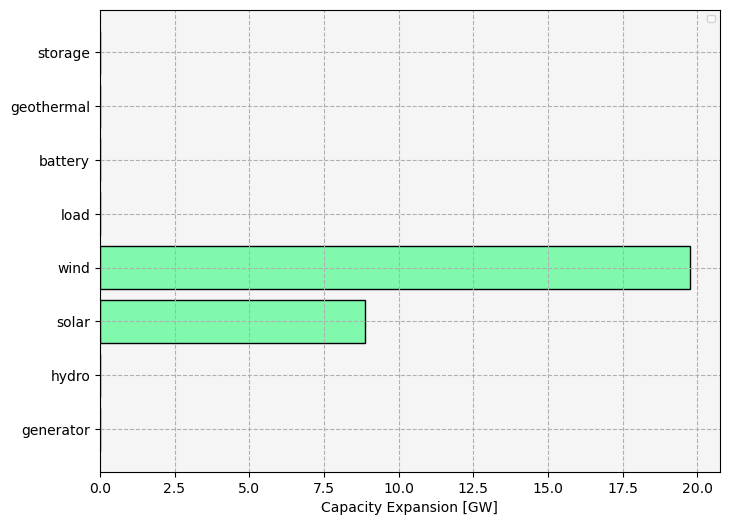

In [11]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)

Now, let's implement custom policies

In [12]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

# for source, node in graph._node.items():
#     for handle, asset in node['assets'].items():

#         if asset['_class'] == 'Store':

#             asset['capex_cost'] = 0
#             print('a')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.85,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

In [13]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 0.7711141109466553
Variables Built: 0.790550947189331
Constraints Built: 4.404662847518921
Objective Built: 0.14608287811279297


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 201658, continuous_variables = 74263, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74263), overall = Bunch(binary_variables = 0, constraints = 201658, continuous_variables = 74263, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74263), warning = Bunch(unassociated_disjuncts = 0))

In [14]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 320.9496810436249
Objective Value: 359435265.93392235


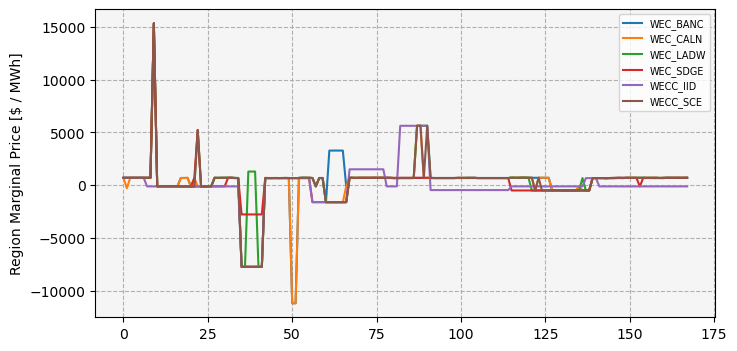

In [15]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

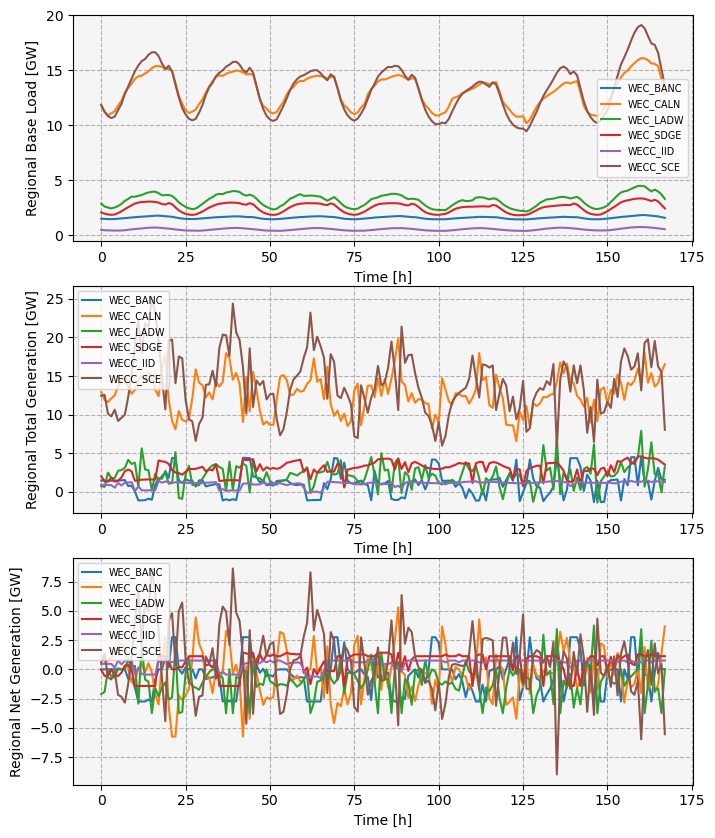

In [16]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

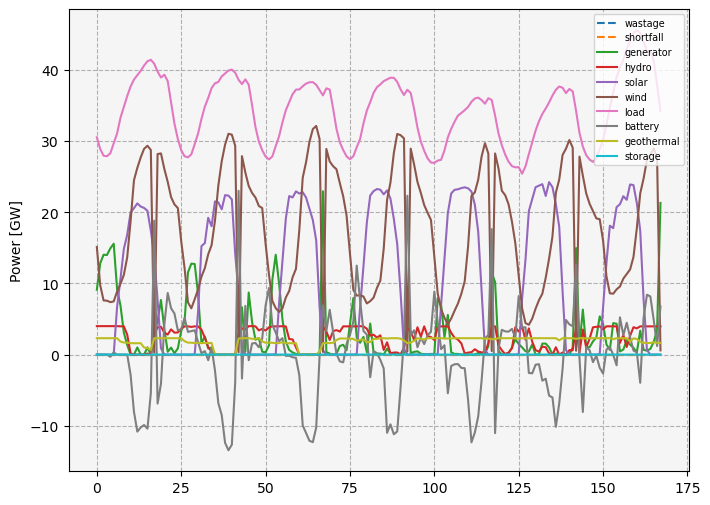

In [17]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

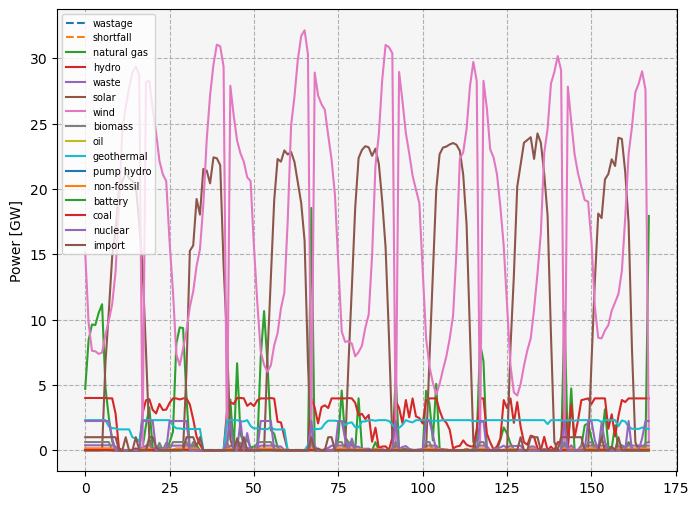

In [18]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


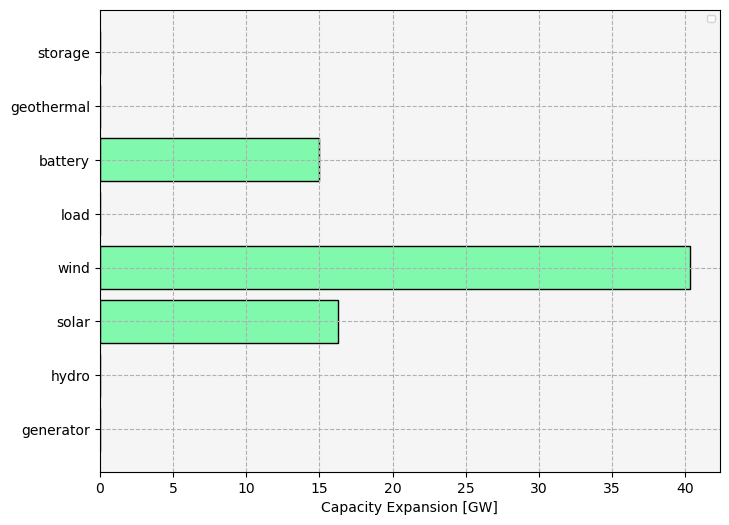

In [19]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)